In [1]:
import mlflow
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

import dataprocessing as dc


In [2]:
spamclass = 1
hamclass = 0
experiment_name = "XGBoost"
metric_to_sort_by = "Average Precision"
ascending = False

experiment = mlflow.get_experiment_by_name(experiment_name)
experiment_id = experiment.experiment_id

runs_df = mlflow.search_runs(experiment_ids=[experiment_id])
runs_df = runs_df[runs_df["status"] == "FINISHED"]

best_run = (
    runs_df
    .sort_values(by=f"metrics.{metric_to_sort_by}", ascending=ascending)
    .iloc[0]
)

best_run_id = best_run["run_id"]
print("Best run ID:", best_run_id)
print("Run name:", best_run["tags.mlflow.runName"])
print(f"Best {metric_to_sort_by}:", best_run[f"metrics.{metric_to_sort_by}"])
model_uri = f"runs:/{best_run_id}/candidate_model"
loaded_model = mlflow.sklearn.load_model(model_uri)

Best run ID: f06a24ad5f8e4a7d8320f06ac4bd8f36
Run name: XGBoost Grid Search
Best Average Precision: 0.8244561197700536


In [3]:
def getDF(filename, spam = -1, ham = 1):
    """
    helper function to load dataset and pass into the preloader

    use spam to set the classifcation of spam to either -1 or 0
    """
    if spam not in [0,-1,1]:
        print(f"getDF spam arguement must be -1 or 0 or 1, was passed spam = {spam}")
        raise AttributeError(f"getDF spam arguement must be -1 or 0 or 1, was passed spam = {spam}")

    df = pd.read_csv(f"data/{filename}")
    newdata = dc.Data_class(data = df, )
    newdata.setSpamClass(spamclass = spam, hamclass= ham)
    df = newdata.data

    return df

def printAcc(model_uri, filename, spamID, hamid, df = None):
    """
    helper function to print the accuracy on the provided datafile
    """
    if df is None:
        df = getDF(filename,spamID,hamid)
    real_messages = df["Category"] == hamid
    spam_messages = df["Category"] == spamID
    y = df["Category"]
    try:
        X_new = df.drop(["Category", "Message", "word_count"], axis=1)
    except KeyError:
        X_new = df.drop(["Category"], axis=1)
    y_real = y[real_messages]
    y_spam = y[spam_messages]
    X_real = X_new[real_messages]
    X_spam = X_new[spam_messages]

    loaded_model = mlflow.sklearn.load_model(model_uri)

    predictions_all = loaded_model.predict(X_new)
    predictions_real = loaded_model.predict(X_real)
    predictions_spam = loaded_model.predict(X_spam)

    accuracy_all = accuracy_score(y, predictions_all)
    accuracy_real = accuracy_score(y_real, predictions_real)
    accuracy_spam = accuracy_score(y_spam, predictions_spam)
    print(f"Accuracy metrics on {filename}")
    print(f"Accuracy on all messages: {accuracy_all:.5%}")
    print(f"Accuracy on real messages: {accuracy_real:.5%}")
    print(f"Accuracy on spam messages: {accuracy_spam:.5%}")
    return accuracy_all, accuracy_real, accuracy_spam

In [4]:
results = []

# email_data.csv
email_a, email_r, email_s = printAcc(model_uri, "email_data.csv", spamclass,hamclass)
results.append(("email_data.csv", email_a, email_r, email_s))

# smishingDataset.csv
smish_a, smish_r, smish_s = printAcc(model_uri, "smishingDataset.csv", spamclass,hamclass)
results.append(("smishingDataset.csv", smish_a, smish_r, smish_s))

# spambase.csv
datafile = "spambase.csv"
df = pd.read_csv(f"data/{datafile}")
df["Category"] = np.where(df['Category'] == 1, spamclass, hamclass)
base_a, base_r, base_s = printAcc(model_uri, datafile, spamclass, hamclass, df=df)
results.append((datafile, base_a, base_r, base_s))

# hf-Marketing.csv nans on non spam
datafile = "hf-Marketing.csv"
df = pd.read_csv(f"data/{datafile}", header=None)
df.columns = ["Message"]

newdata = dc.Data_class(data=df)
df = newdata.data
df["Category"] = spamclass
y = df["Category"]
X_new = df.drop(["Category", "Message", "word_count"], axis=1)
loaded_model = mlflow.sklearn.load_model(model_uri)
predictions_all = loaded_model.predict(X_new)
accuracy_spam = accuracy_score(y, predictions_all)
print(f"Accuracy metrics on {datafile}")
print(f"Accuracy on spam messages: {accuracy_spam:.3%}")

results.append((datafile, np.nan, np.nan, accuracy_spam))

results_df = pd.DataFrame(
    results,
    columns=["id", "accuracy_all", "accuracy_real", "accuracy_spam"],
)


Accuracy metrics on email_data.csv
Accuracy on all messages: 97.09261%
Accuracy on real messages: 98.90155%
Accuracy on spam messages: 85.40830%
Accuracy metrics on smishingDataset.csv
Accuracy on all messages: 88.10919%
Accuracy on real messages: 89.06449%
Accuracy on spam messages: 76.82403%
Accuracy metrics on spambase.csv
Accuracy on all messages: 55.55314%
Accuracy on real messages: 86.33429%
Accuracy on spam messages: 8.21842%
Accuracy metrics on hf-Marketing.csv
Accuracy on spam messages: 14.477%


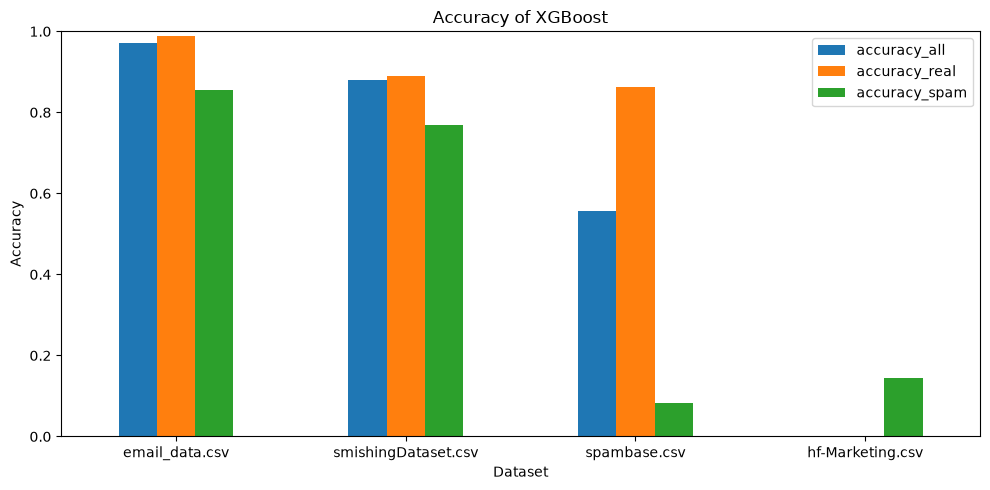

In [7]:
import matplotlib.pyplot as plt

results_df.set_index("id")[["accuracy_all", "accuracy_real", "accuracy_spam"]] \
    .plot(kind="bar", figsize=(10, 5), ylim=(0, 1))
plt.ylabel("Accuracy")
plt.xlabel("Dataset")
plt.title(f"Accuracy of {experiment_name}")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("./figs/Accuracy of XGBoost by Dataset.svg", format = "svg", bbox_inches="tight")
plt.show()